In [1]:
# 05_logistic_regression_baseline.ipynb
# Train and evaluate Logistic Regression on Top-7 features.
# Saves model and metrics to ../artifacts/

In [3]:
import os, json, joblib, time
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import matplotlib.pyplot as plt

%matplotlib inline

# Paths (adjust if needed)
DATA_PATH = "../data/heart_uci.csv"
FEATURE_MAP = "../artifacts/feature_index_map.json"   # must exist
OUT_DIR = "../figures"
ART_DIR = "../artifacts"
MODEL_OUT = os.path.join(ART_DIR, "lr_top7.joblib")
METRICS_OUT = os.path.join(ART_DIR, "lr_metrics_k7.json")
COEFFS_OUT = os.path.join(ART_DIR, "lr_coeffs_k7.csv")
COMPARE_CSV = os.path.join(ART_DIR, "model_comparison.csv")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(ART_DIR, exist_ok=True)
print("Artifacts will be saved to:", ART_DIR)

Artifacts will be saved to: ../artifacts


In [4]:
# Cell 2: load data and holdout split (same seed as calibration)
df = pd.read_csv(DATA_PATH)
df['num'] = (df['num'] > 0).astype(int)
X_df = df.drop(columns=['num'])
y = df['num'].values

# reproducible holdout (same as calibration notebook)
X_train, X_hold, y_train, y_hold = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)
print("Train / Hold sizes:", len(y_train), len(y_hold))

Train / Hold sizes: 736 184


In [5]:
# Cell 3: reconstruct preprocessor exactly as used previously
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = ['age','trestbps','chol','thalch','oldpeak','ca']
categorical_features = ['sex','cp','fbs','restecg','exang','slope','thal']

# reconstruct categories list from full df (same technique as earlier)
categories_list = [sorted(X_df[c].dropna().unique().tolist()) for c in categorical_features]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, categories=categories_list))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

# fit the preprocessor on TRAIN only (to avoid leakage)
preprocessor.fit(X_train)
# get full transformed feature names (25)
def get_feature_names(ct):
    names=[]
    for name, transformer, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps"):
            last = list(transformer.named_steps.values())[-1]
            if hasattr(last, "get_feature_names_out"):
                out = last.get_feature_names_out(cols)
                names.extend(out.tolist())
            else:
                names.extend(list(cols))
        else:
            if hasattr(transformer, "get_feature_names_out"):
                names.extend(transformer.get_feature_names_out(cols).tolist())
            else:
                names.extend(list(cols))
    return names

full_feature_names = get_feature_names(preprocessor)
print("Total transformed features:", len(full_feature_names))
print(full_feature_names[:10], "...")

Total transformed features: 25
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina'] ...


In [6]:
# Cell 4: transform X_train and X_hold, then select Top-7 columns by name
X_train_trans = preprocessor.transform(X_train)
X_hold_trans = preprocessor.transform(X_hold)

# convert to DataFrame for easy column selection
X_train_df_trans = pd.DataFrame(X_train_trans, columns=full_feature_names, index=X_train.index)
X_hold_df_trans  = pd.DataFrame(X_hold_trans, columns=full_feature_names, index=X_hold.index)

# load top7 mapping
meta = json.load(open(FEATURE_MAP,"r"))
top7 = meta["selected_features"]
top7_indices = meta["selected_indices"]
print("Top7 features:", top7)
print("Top7 indices:", top7_indices)

# subset
X_train_top7 = X_train_df_trans[top7].copy()
X_hold_top7  = X_hold_df_trans[top7].copy()
print("Top7 shapes:", X_train_top7.shape, X_hold_top7.shape)

Top7 features: ['cp_asymptomatic', 'exang_False', 'cp_atypical angina', 'chol', 'sex_Female', 'oldpeak', 'thal_normal']
Top7 indices: [8, 17, 9, 2, 6, 4, 23]
Top7 shapes: (736, 7) (184, 7)


In [7]:
# Cell 5: train Logistic Regression with GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}  # simple grid
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=42)

gs = GridSearchCV(lr, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
t0 = time.time()
gs.fit(X_train_top7, y_train)
t1 = time.time()
print("GridSearch done. Best params:", gs.best_params_, "Best CV ROC-AUC:", gs.best_score_)
print("Training time (s):", t1-t0)

best_lr = gs.best_estimator_
joblib.dump(best_lr, MODEL_OUT)
print("Saved LR model to:", MODEL_OUT)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
GridSearch done. Best params: {'C': 1.0} Best CV ROC-AUC: 0.8705182356537369
Training time (s): 14.476996898651123
Saved LR model to: ../artifacts\lr_top7.joblib


In [8]:
# Cell 6: evaluate on holdout
probs_lr = best_lr.predict_proba(X_hold_top7)[:,1]
roc_lr = roc_auc_score(y_hold, probs_lr)
ap_lr = average_precision_score(y_hold, probs_lr)
brier_lr = brier_score_loss(y_hold, probs_lr)

print("LR Holdout metrics — ROC-AUC: %.4f, AP: %.4f, Brier: %.4f" % (roc_lr, ap_lr, brier_lr))

# save metrics
lr_metrics = {
    "model": "LogisticRegression",
    "features": "Top-7",
    "roc_auc": float(roc_lr),
    "avg_precision": float(ap_lr),
    "brier": float(brier_lr),
    "best_params": gs.best_params_,
    "train_time_s": float(t1-t0)
}
json.dump(lr_metrics, open(METRICS_OUT,"w"), indent=2)
print("Saved LR metrics to:", METRICS_OUT)

LR Holdout metrics — ROC-AUC: 0.9216, AP: 0.9407, Brier: 0.1146
Saved LR metrics to: ../artifacts\lr_metrics_k7.json


In [9]:
# Cell 7: coefficients and odds ratios
coefs = best_lr.coef_.ravel()
coef_df = pd.DataFrame({"feature": top7, "coef": coefs})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df = coef_df.sort_values(by="odds_ratio", ascending=False)
coef_df.to_csv(COEFFS_OUT, index=False)
print("Saved LR coefficients and odds ratios to:", COEFFS_OUT)
print(coef_df)

Saved LR coefficients and odds ratios to: ../artifacts\lr_coeffs_k7.csv
              feature      coef  odds_ratio
0     cp_asymptomatic  1.224029    3.400861
5             oldpeak  0.565582    1.760471
3                chol -0.426311    0.652913
6         thal_normal -0.731313    0.481277
2  cp_atypical angina -0.829085    0.436448
1         exang_False -1.065501    0.344555
4          sex_Female -1.125389    0.324526


In [10]:
# Cell 8: append LR metrics to model_comparison.csv (create if needed)
import csv
row = {
    "model": "LogisticRegression",
    "features": "Top-7",
    "roc_auc": lr_metrics["roc_auc"],
    "avg_precision": lr_metrics["avg_precision"],
    "brier": lr_metrics["brier"],
    "params": str(lr_metrics["best_params"]),
    "train_time_s": lr_metrics["train_time_s"],
    "artifact": os.path.basename(MODEL_OUT)
}
# create file with header if not present
if not os.path.exists(COMPARE_CSV):
    df0 = pd.DataFrame([row])
    df0.to_csv(COMPARE_CSV, index=False)
else:
    df_existing = pd.read_csv(COMPARE_CSV)
    df_existing = pd.concat([df_existing, pd.DataFrame([row])], ignore_index=True)
    df_existing.to_csv(COMPARE_CSV, index=False)

print("Appended LR results to", COMPARE_CSV)

Appended LR results to ../artifacts\model_comparison.csv


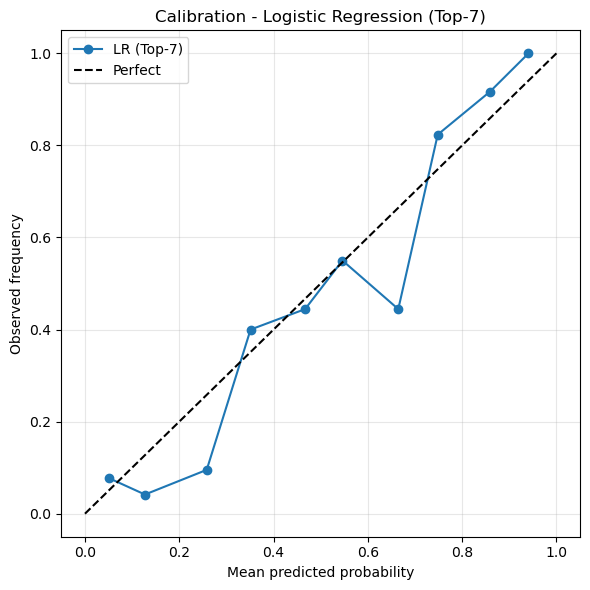

LR ECE: 0.0730733244918549


C:\Users\Nikhil\AppData\Local\Temp\ipykernel_4164\3581666951.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = dfc.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()


In [11]:
# Cell 9: calibration diagnostics for LR (plot + ECE)
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_hold, probs_lr, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="LR (Top-7)")
plt.plot([0,1],[0,1],"k--", label="Perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration - Logistic Regression (Top-7)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "calibration_lr_top7.png"), dpi=250)
plt.show()

# ECE
def calibration_table(y_true, probs, n_bins=10):
    dfc = pd.DataFrame({"y": y_true, "p": probs})
    dfc["bin"] = pd.cut(dfc["p"], bins=np.linspace(0,1,n_bins+1), include_lowest=True)
    table = dfc.groupby("bin").agg(n=("y","size"), mean_pred=("p","mean"), frac_pos=("y","mean")).reset_index()
    table["abs_error"] = (table["mean_pred"] - table["frac_pos"]).abs()
    ece = (table["n"] * table["abs_error"]).sum() / table["n"].sum()
    return ece, table

ece_lr, table_lr = calibration_table(y_hold, probs_lr, n_bins=10)
print("LR ECE:", ece_lr)
table_lr.to_csv(os.path.join(ART_DIR,"calib_table_lr_top7.csv"), index=False)
